In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain.chat_models import init_chat_model

model = init_chat_model("google_genai:gemini-3.1-flash-lite")

In [3]:
from typing import TypedDict

class State(TypedDict):
    message: str

In [4]:
def generate(state):
    message = state["message"]
    response = model.invoke(message)
    return {"message": response}

In [5]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

graph_builder.add_node(generate)

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

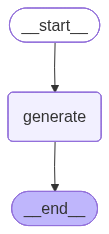

In [6]:
graph

In [7]:
graph.invoke({"message": "대한민국의 수도는?"})

{'message': AIMessage(content=[{'type': 'text', 'text': '대한민국의 수도는 **서울특별시**입니다.', 'extras': {'signature': 'EjQKMgEMOdbHm0PPQv9FCJ37lpQwA0ORdIvY9yGhhlaIddh5mOMdkVllCv3fljDqkY3h79/p'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ea0c4-24ec-7d50-8a4d-742bddf489f1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 10, 'total_tokens': 17, 'input_token_details': {'cache_read': 0}})}